<a href="https://colab.research.google.com/github/AbdurRakibNaiem/Federated-Healthcare-AI/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Name: **Md. Abdur Rakib**
* Roll: **2571554**
* Course: Special Study in Information and Communication Technology (Federated AI Security for Healthcare)

# Short Notes on Scikit-Learn Algorithms:

* **Random Forest (`sklearn.ensemble.RandomForestClassifier`):**
An ensemble learning method that constructs a multitude of decision trees during training and outputs the mode of the classes for classification, generally robust against overfitting.

* **K-Nearest Neighbors (`sklearn.neighbors.KNeighborsClassifier`):**
A non-parametric method that classifies a sample based on the majority class among its 'k' closest neighbors in the feature space.

* **Decision Tree (`sklearn.tree.DecisionTreeClassifier`):**
A model that uses a tree-like graph of decisions and their possible consequences, highly interpretable but prone to overfitting if not tuned.

* **Gradient Boosting (`sklearn.ensemble.GradientBoostingClassifier`):**
Builds an additive model in a forward stage-wise fashion, optimizing arbitrary differentiable loss functions, often yielding high performance.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [47]:
# Loading the dataset
#'Heart_Disease_Prediction.csv' is uploaded to the Colab environment
#Dataset Link: https://drive.google.com/file/d/1sH6EjhDOroFG8dbS0CU43aGzFX1QaMaa/view?usp=sharing
try:
    df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/IICT MSc Course /Assignment1/Heart_Disease_Prediction.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Heart_Disease_Prediction.csv' not found. Please upload it to your Colab session.")

Dataset loaded successfully.


In [48]:
# Data Cleaning: Drop the irrelevant 'index' column
if 'index' in df.columns:
    df.drop(columns=["index"], inplace=True)

In [49]:
# Renaming columns for consistency
df.rename(columns={
    "Chest pain type":"Chest_pain_type",
    "FBS over 120":"FBS_over_120",
    "EKG results":"EKG_results",
    "Max HR":"Max_HR",
    "Exercise angina":"Exercise_angina",
    "ST depression":"ST_depression",
    "Slope of ST":"Slope_of_ST",
    "Number of vessels fluro":"Vessels_fluro",
    "Heart Disease":"Heart_Disease"}, inplace=True)

print("\nFirst 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Vessels_fluro,Thallium,Heart_Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [50]:
# Creating a dataframe excluding the target variable
data = df.loc[:, ~df.columns.isin(["Heart_Disease"])]
num_vars = len(data.columns)

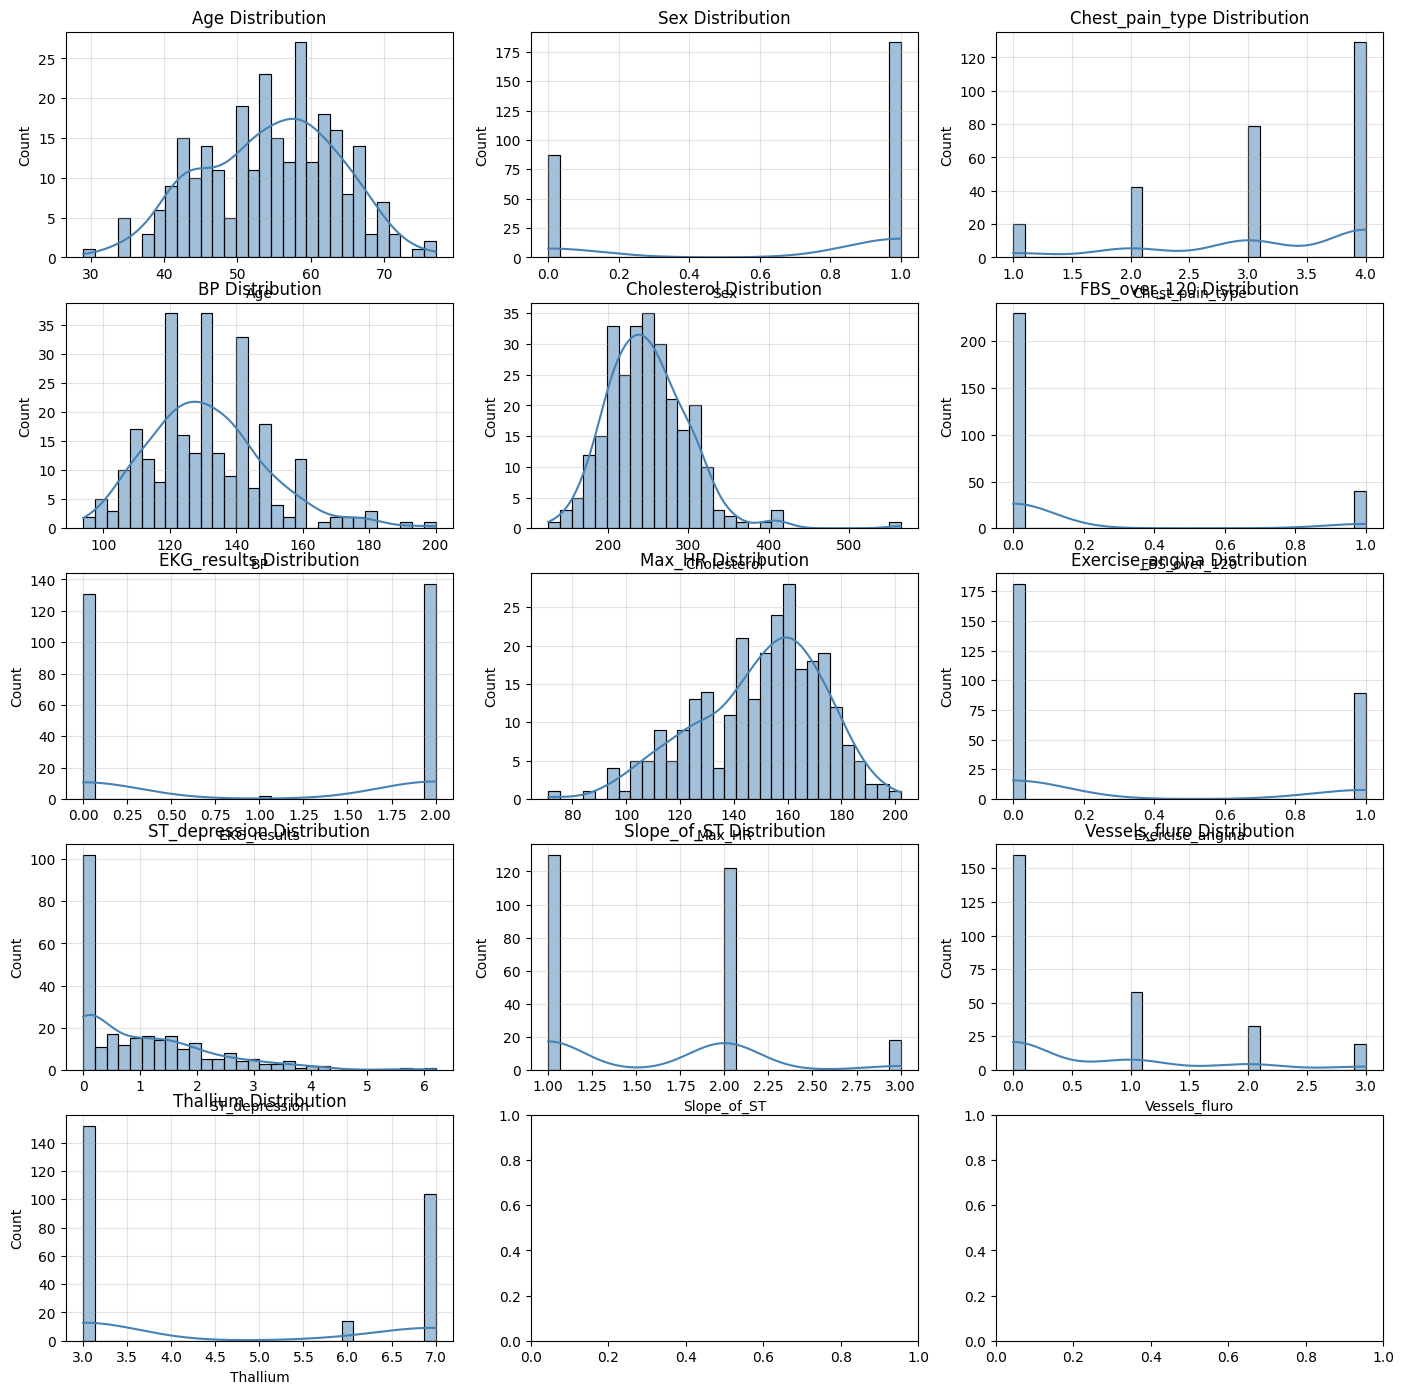

In [51]:
# Calculating grid dimensions dynamically
num_rows = (num_vars // 3) + (1 if num_vars % 3 != 0 else 0)
num_cols = 3

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(17, 17))
axes = axes.flatten()

for i, col in enumerate(data.columns):
    sns.histplot(data[col], bins=30, ax=axes[i], color="steelblue", kde=True)
    axes[i].set_title(f"{col} Distribution")
    axes[i].grid(alpha=0.35)

In [52]:
# Removing empty subplots
for j in range(num_vars, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histograms for Independent Features", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

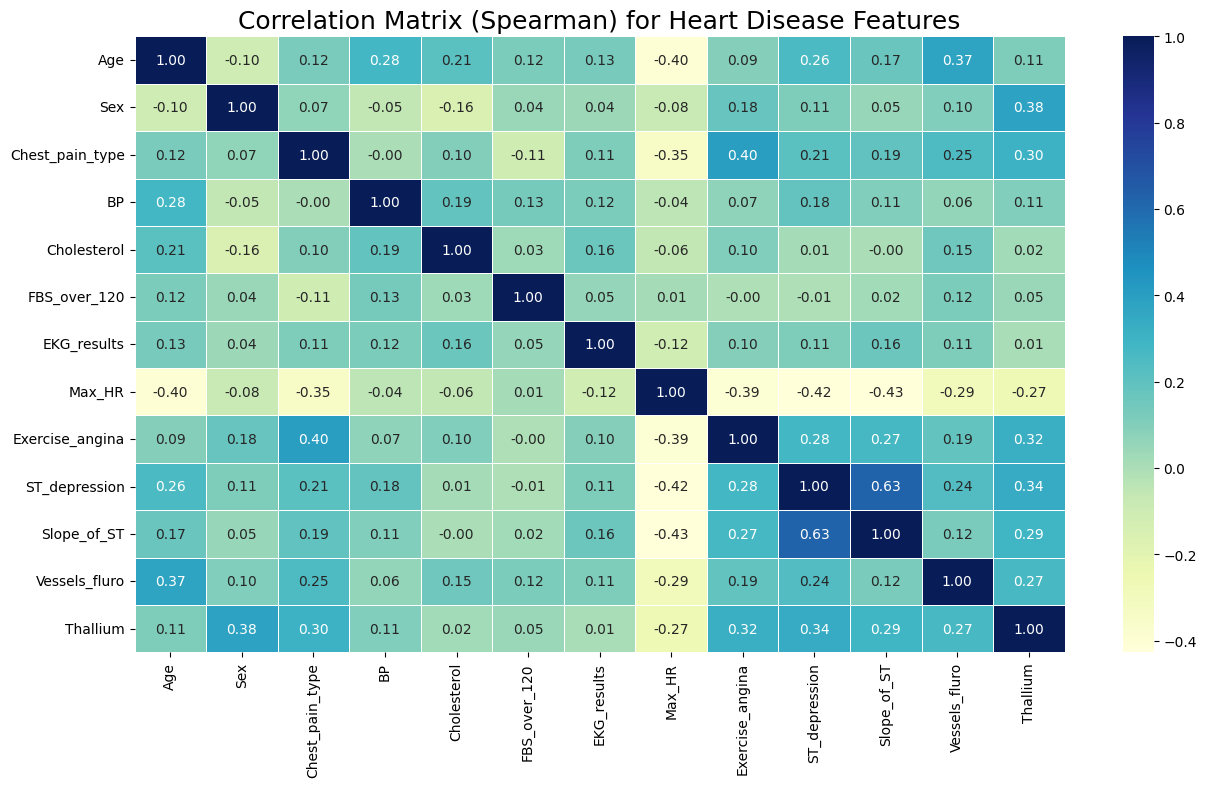

In [53]:
# Calculating Spearman correlation matrix
corr_matrix = data.corr(method="spearman")

plt.figure(figsize=[15, 8])
sns.heatmap(data=corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix (Spearman) for Heart Disease Features", fontsize=18)
plt.show()

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.exceptions import NotFittedError

In [55]:
X = data
y = df['Heart_Disease']

# Spliting the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
# Defining the scaler
scaler = StandardScaler()

In [57]:
# Creating Pipelines
# Pipeline 1: StandardScaler + Logistic Regression
pipeline_lr = Pipeline(steps=[
    ('preprocessor', scaler),
    ('classifier', LogisticRegression(random_state=42))
])

In [58]:
# Pipeline 2: StandardScaler + Support Vector Machine (Linear Kernel)
pipeline_svm = Pipeline(steps=[
    ('preprocessor', scaler),
    ('classifier', SVC(kernel='linear', random_state=42, probability=True))
])

In [59]:
# Dictionary to hold models for easy iteration
models = {
    'Logistic Regression': pipeline_lr,
    'Support Vector Machine': pipeline_svm
}


Evaluating Model: Logistic Regression
Accuracy:    0.9074
Precision:   0.9000
Recall:      0.8571
Specificity: 0.9394


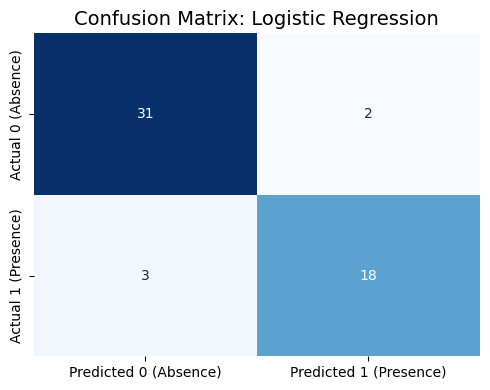


Evaluating Model: Support Vector Machine
Accuracy:    0.8889
Precision:   0.8947
Recall:      0.8095
Specificity: 0.9394


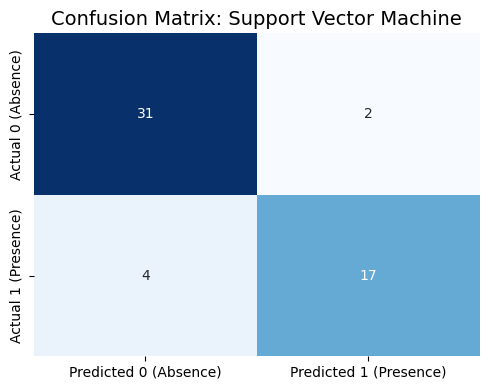

In [60]:
# Iterating through models, train, predict, and evaluate

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Evaluating Model: {name}")
    print(f"{'='*40}")

    # Fitting the pipeline on training data
    model.fit(X_train, y_train)

    # Predicting on test data
    y_pred = model.predict(X_test)

    # Calculating Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculating Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='Presence')
    rec = recall_score(y_test, y_pred, pos_label='Presence')
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Displaying Metrics
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Recall:      {rec:.4f}")
    print(f"Specificity: {spec:.4f}")

    # Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0 (Absence)', 'Predicted 1 (Presence)'],
                yticklabels=['Actual 0 (Absence)', 'Actual 1 (Presence)'])
    plt.title(f'Confusion Matrix: {name}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [61]:
# =====================================================================
# INTERACTIVE PATIENT DATA ENTRY FORM
# =====================================================================
#@title 🩺 Enter Patient Details for Heart Disease Prediction { display-mode: "form" }

Age = 30 #@param {type:"slider", min:20, max:100, step:1}
Sex = "Male" #@param ["Male", "Female"]
Chest_Pain_Type = "1: Typical angina" #@param ["1: Typical angina", "2: Atypical angina", "3: Non-anginal pain", "4: Asymptomatic"]
Resting_Blood_Pressure = 70 #@param {type:"integer"}
Cholesterol_mg_dl = 245 #@param {type:"integer"}
Fasting_Blood_Sugar_Over_120 = "No" #@param ["Yes", "No"]
EKG_Results = "0: Normal" #@param ["0: Normal", "1: ST-T wave abnormality", "2: Left ventricular hypertrophy"]
Max_Heart_Rate = 153 #@param {type:"integer"}
Exercise_Induced_Angina = "Yes" #@param ["Yes", "No"]
ST_Depression = 0.8 #@param {type:"number"}
Slope_of_ST_Segment = "2: Flat" #@param ["1: Upsloping", "2: Flat", "3: Downsloping"]
Number_of_Major_Vessels = "0" #@param ["0", "1", "2", "3"]
Thallium_Stress_Test = "3: Normal" #@param ["3: Normal", "6: Fixed defect", "7: Reversable defect"]

# =====================================================================
# DATA PROCESSING & PREDICTION LOGIC
# =====================================================================

#Map the user-friendly dropdown text back to numerical values expected by the model
patient_data = {
    "Age": Age,
    "Sex": 1 if Sex == "Male" else 0,
    "Chest_pain_type": int(Chest_Pain_Type[0]),
    "BP": Resting_Blood_Pressure,
    "Cholesterol": Cholesterol_mg_dl,
    "FBS_over_120": 1 if Fasting_Blood_Sugar_Over_120 == "Yes" else 0,
    "EKG_results": int(EKG_Results[0]),
    "Max_HR": Max_Heart_Rate,
    "Exercise_angina": 1 if Exercise_Induced_Angina == "Yes" else 0,
    "ST_depression": ST_Depression,
    "Slope_of_ST": int(Slope_of_ST_Segment[0]),
    "Vessels_fluro": int(Number_of_Major_Vessels),
    "Thallium": int(Thallium_Stress_Test[0])
}

In [62]:
# Converting to DataFrame
patient_df = pd.DataFrame([patient_data])

In [63]:
# Defining a function to evaluate and print results nicely
def evaluate_patient(model_pipeline, model_name):
    # Predicting class (0 or 1) and calculate probabilities
    prediction = model_pipeline.predict(patient_df)[0]
    probabilities = model_pipeline.predict_proba(patient_df)[0]

    # Extracting confidence percentage
    confidence = probabilities[1] if prediction == 1 else probabilities[0]
    diagnosis = "⚠️ PRESENCE of Heart Disease Detected" if prediction == 1 else "✅ ABSENCE of Heart Disease Detected"

    print(f"--- {model_name} ---")
    print(f"Diagnosis  : {diagnosis}")
    print(f"Confidence : {confidence * 100:.2f}%\n")

In [64]:
# Running the predictions (assuming pipeline_lr and pipeline_svm are already in memory from the previous cell)
print("================ CLINICAL PREDICTION RESULTS ================\n")
try:
    evaluate_patient(pipeline_lr, "Logistic Regression")
    evaluate_patient(pipeline_svm, "Support Vector Machine")
except NotFittedError:
    print("Error: The models have not been trained yet. Please make sure you have run the model training cell (containing the 'for name, model in models.items():' loop) to fit the models before making predictions.")
except NameError:
    print("Error: The models (pipeline_lr or pipeline_svm) are not defined. Please make sure you have run the model creation cells first.")

================ CLINICAL PREDICTION RESULTS ================

--- Logistic Regression ---
Diagnosis  : ✅ ABSENCE of Heart Disease Detected
Confidence : 95.20%

--- Support Vector Machine ---
Diagnosis  : ✅ ABSENCE of Heart Disease Detected
Confidence : 84.76%

